<center><span style="font-size:60px;"><b>METRICS ANALYSIS</b></span></center>

In [1]:
# IMPORTS
import os
import math
import glob
import time
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt


import torch
import torchvision.transforms as T

We apply metrics to both whole image and hole-only patch. This is because with hole-only we evaluate the generated patch excluding the sorrounding frame (which is basically copied from grounf truth) while with the whole image we evaluate also the global consistency of the resulting image.

---

---

---

# LOAD RESULTS

In [6]:
# LOAD RESULTS
metrics_array = np.load("./metrics_results/metrics_200img_48masks_iizuka_no_blending.npy")
mean_metrics = np.load("./metrics_results/mean_metrics_200img_48masks_iizuka_no_blending.npy", allow_pickle=True).item()

metric_names = ["L1", "PSNR", "SSIM", "LPIPS"]

In [5]:
metrics_array[:4,:9,2]  # debug

array([[0.6401864 , 0.6324207 , 0.6457043 , 0.3703949 , 0.37285635,
        0.3702787 , 0.2537759 , 0.2584827 , 0.25505066],
       [0.8172576 , 0.8123225 , 0.82111156, 0.5855417 , 0.58701164,
        0.58442384, 0.41547704, 0.42431557, 0.4189508 ],
       [0.71949023, 0.7144904 , 0.72691035, 0.4064536 , 0.41543627,
        0.41137108, 0.29447693, 0.29378903, 0.29204652],
       [0.7229385 , 0.72518325, 0.72688097, 0.5605828 , 0.5611886 ,
        0.56413144, 0.431345  , 0.4323051 , 0.4380672 ]], dtype=float32)

---

# MASK AND IMAGES ANALYSIS

In [7]:
def plot_metric_histograms(metrics_array, metric_names):
    """
    Plots histogram of each metric over all (image, mask) pairs.
    """

    N_metrics = metrics_array.shape[2]

    for k in range(N_metrics):
        values = metrics_array[:, :, k].flatten()

        plt.figure(figsize=(15,4))
        plt.hist(values, bins=70)
        plt.title(f"Distribution of {metric_names[k]}")
        plt.xlabel(metric_names[k])
        plt.ylabel("Frequency")
        plt.grid(alpha=0.4)
        plt.show()

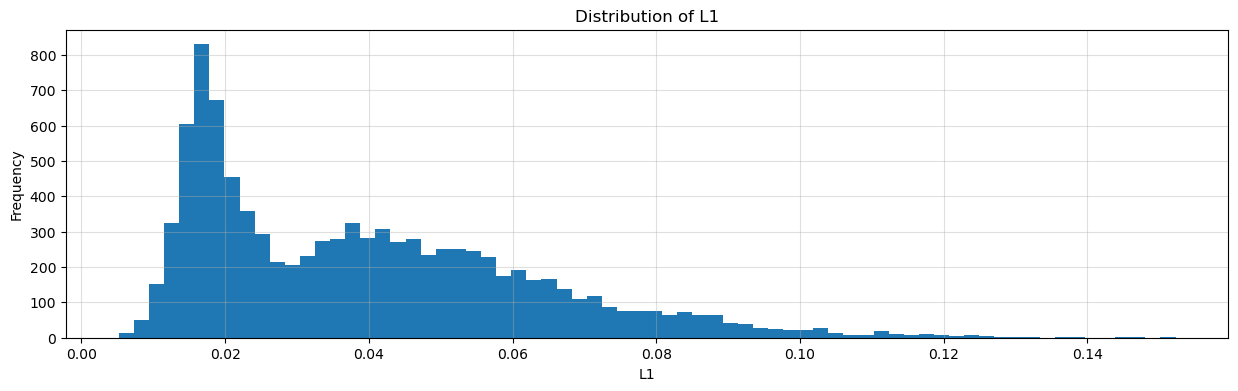

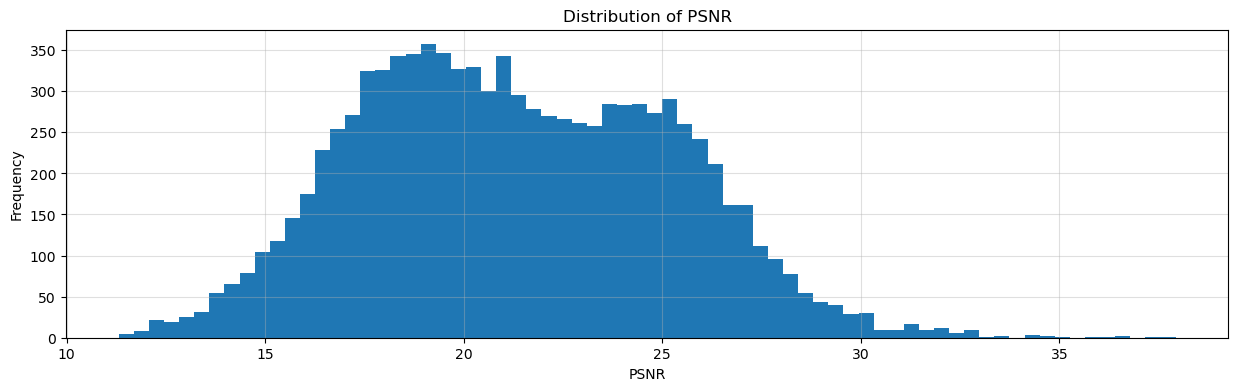

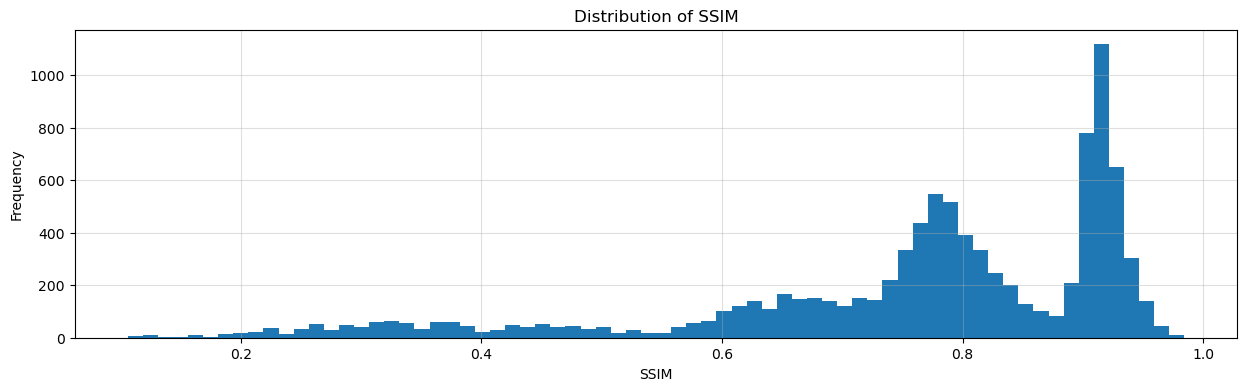

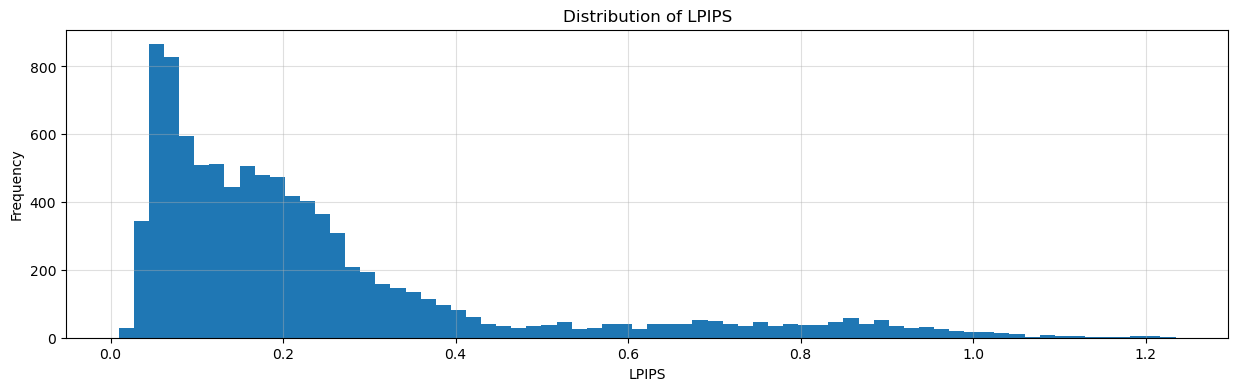

In [8]:
plot_metric_histograms(metrics_array, metric_names)

In [11]:
def plot_heatmap(metrics_array, metric_names):
    """
    Heatmap for each metric (images x masks) displayed in a two-column grid.
    """
    num_metrics = len(metric_names)
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    
    # Flatten axes array for easy 1D iteration (handles 1D or 2D axes array)
    axes_flat = axes.flatten() if num_metrics > 1 else [axes]

    for k, name in enumerate(metric_names):
        ax = axes_flat[k]
        im = ax.imshow(metrics_array[:, :, k], aspect='auto')
        fig.colorbar(im, ax=ax, label=name)
        ax.set_title(f"{name} heatmap (images x masks)")
        ax.set_xlabel("Mask index")
        ax.set_ylabel("Image index")

    # Hide any unused subplots in the grid if num_metrics is odd
    for k in range(num_metrics, len(axes_flat)):
        fig.delaxes(axes_flat[k])

    plt.tight_layout()
    plt.show()

Let's search for:
* hard masks (vertical stripes)
* hard images (horizontal stripes)

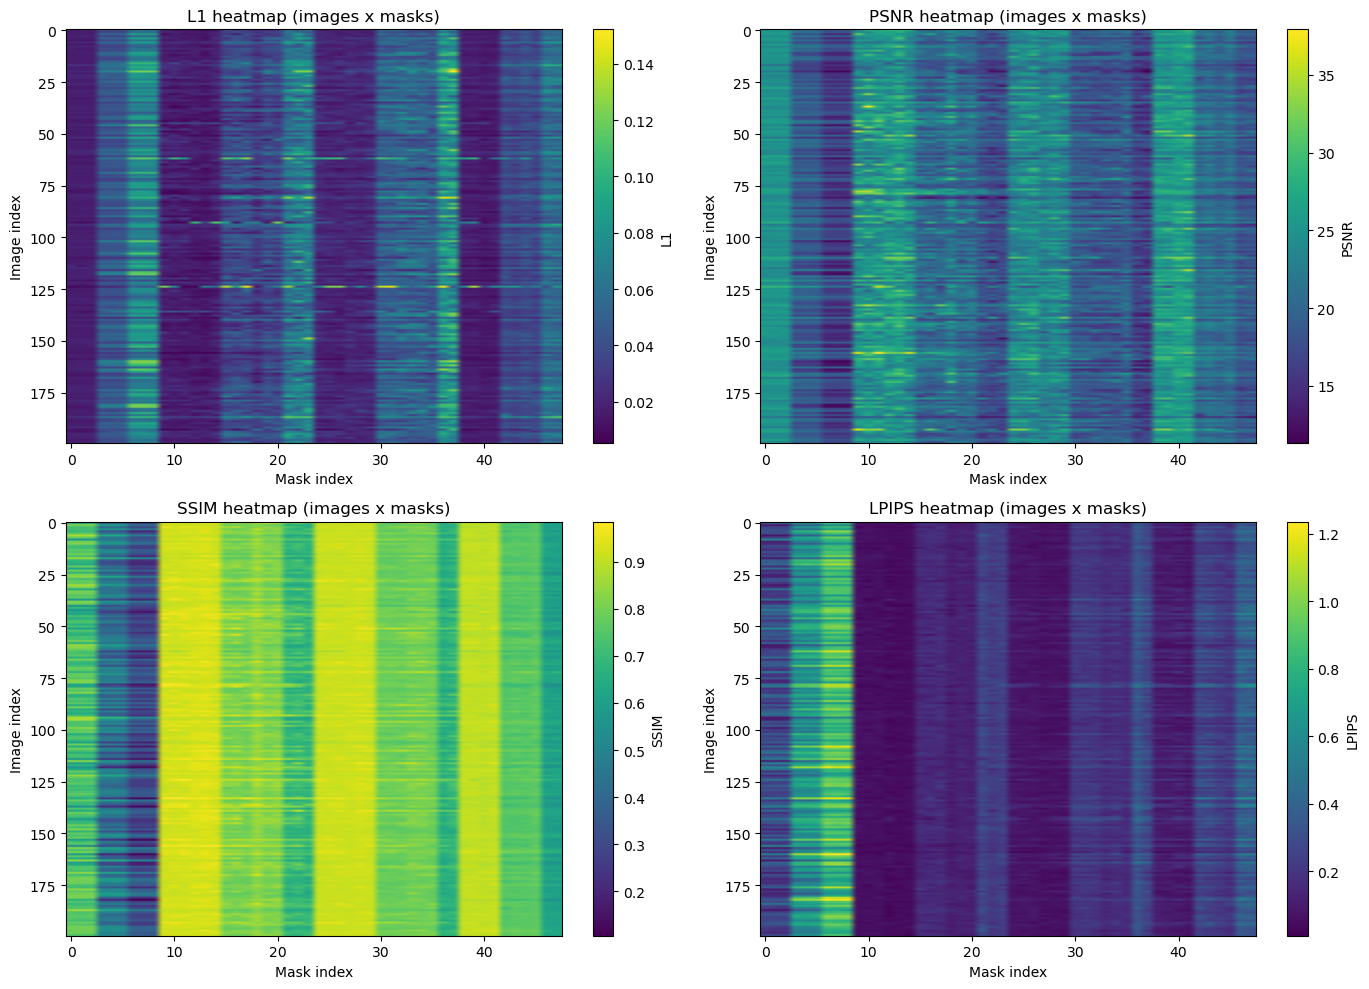

In [12]:
plot_heatmap(metrics_array, metric_names)

In [13]:
def plot_mask_difficulty(metrics_array, metric_names):
    """
    Average metric per mask in a 2-column layout.
    """
    mask_means = metrics_array.mean(axis=0)  # (M, K)
    
    num_metrics = len(metric_names)
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)

    for k, name in enumerate(metric_names):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        
        ax.plot(mask_means[:, k], marker='o')
        ax.set_title(f"{name} vs Mask index")
        ax.set_xlabel("Mask index")
        ax.set_ylabel(name)
        ax.grid(True)

    # Hide unused subplots if the total count is odd
    for k in range(num_metrics, rows * cols):
        r, c = divmod(k, cols)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    plt.show()

Search for hardest masks:

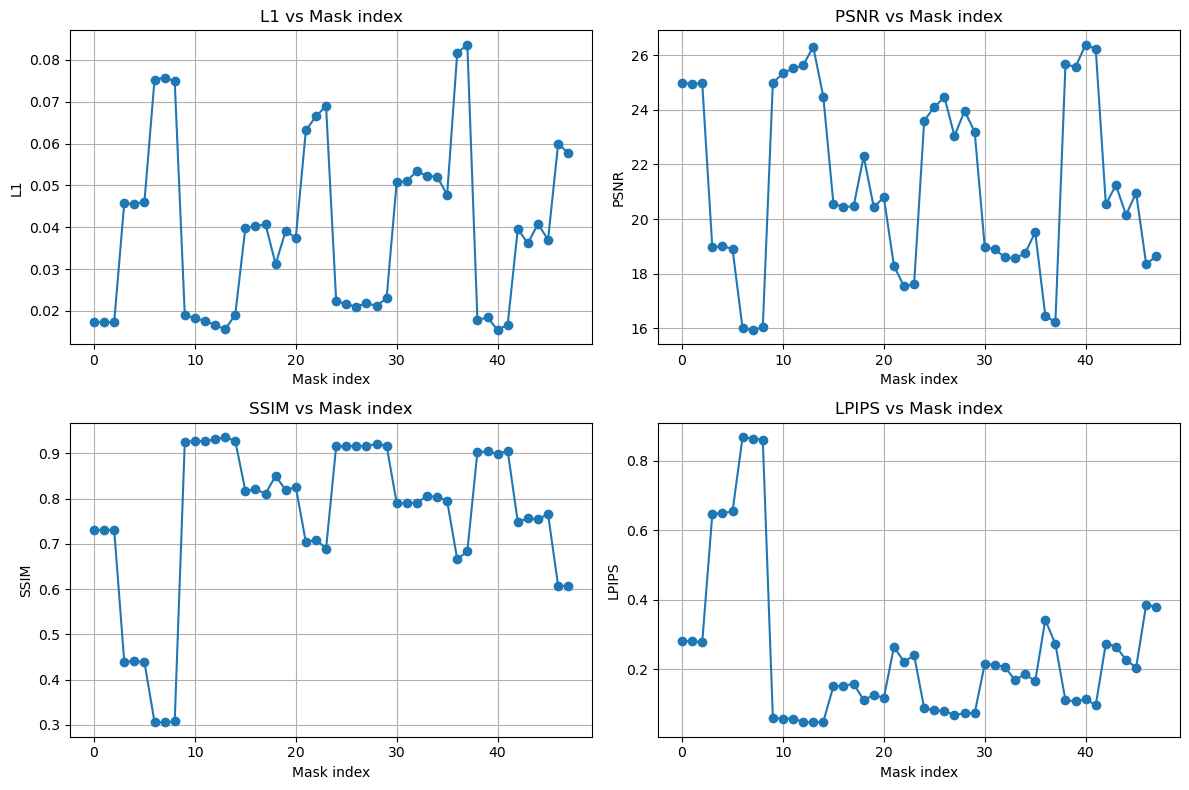

In [14]:
plot_mask_difficulty(metrics_array, metric_names)

In [15]:
def plot_image_difficulty(metrics_array, metric_names):
    """
    Average metric per image displayed in a two-column grid.
    """
    image_means = metrics_array.mean(axis=1)  # (N, K)
    num_metrics = len(metric_names)

    # Calculate required rows for a 2-column layout
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()  # Flatten to a 1D array for easy iteration

    for k, name in enumerate(metric_names):
        ax = axes[k]
        ax.plot(image_means[:, k])
        ax.set_title(f"{name} vs Image index")
        ax.set_xlabel("Image index")
        ax.set_ylabel(name)
        ax.grid(True)

    # Hide any unused subplots if the metric count is odd
    for k in range(num_metrics, len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

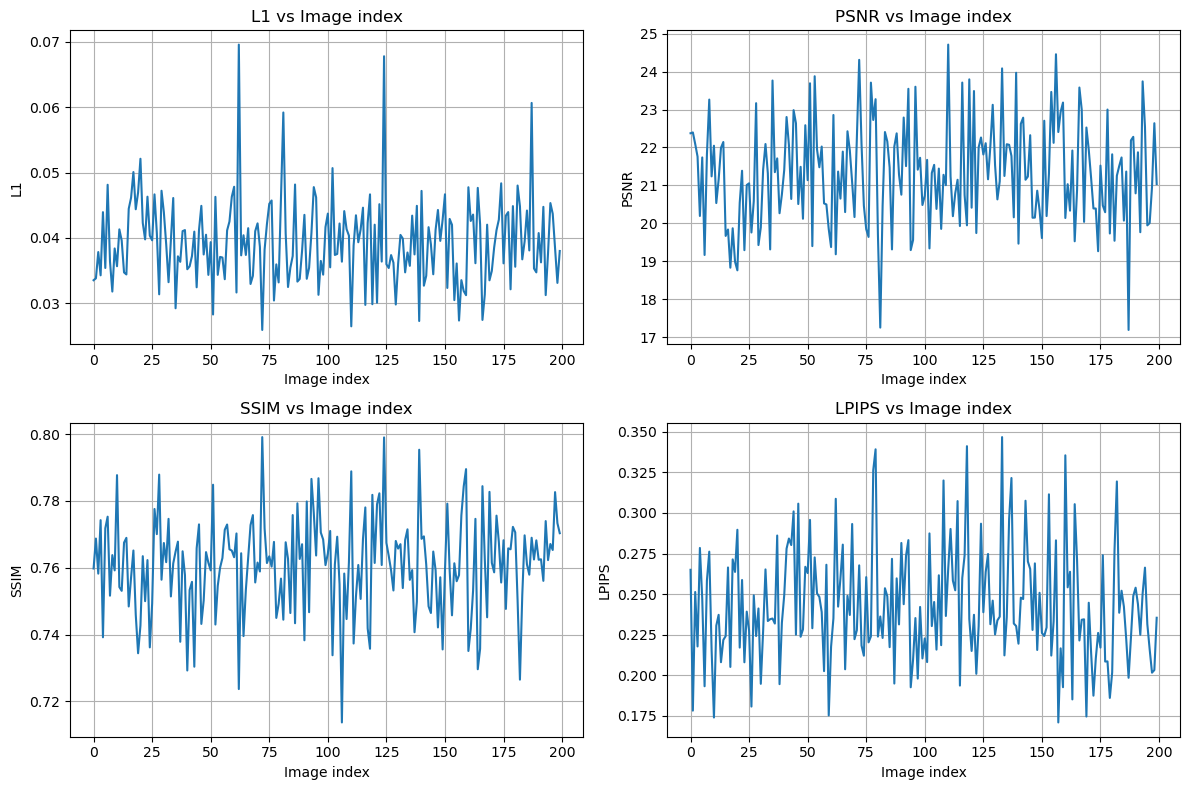

In [16]:
plot_image_difficulty(metrics_array, metric_names)

In [17]:
def find_extreme_cases(metrics_array, metric_names):
    """
    Finds min/max values and their (image, mask) positions.
    """

    results = {}

    for k, name in enumerate(metric_names):
        metric_values = metrics_array[:, :, k]

        min_idx = metric_values.argmin()
        max_idx = metric_values.argmax()

        min_pos = np.unravel_index(min_idx, metric_values.shape)
        max_pos = np.unravel_index(max_idx, metric_values.shape)

        results[name] = {
            "min_value": metric_values[min_pos],
            "min_pos": min_pos,
            "max_value": metric_values[max_pos],
            "max_pos": max_pos,
        }

    return results

In [21]:
results = find_extreme_cases(metrics_array, metric_names)
results

{'L1': {'min_value': np.float32(0.0051931744),
  'min_pos': (np.int64(156), np.int64(14)),
  'max_value': np.float32(0.1522873),
  'max_pos': (np.int64(20), np.int64(37))},
 'PSNR': {'min_value': np.float32(11.310001),
  'min_pos': (np.int64(20), np.int64(37)),
  'max_value': np.float32(37.924545),
  'max_pos': (np.int64(156), np.int64(11))},
 'SSIM': {'min_value': np.float32(0.10577865),
  'min_pos': (np.int64(182), np.int64(6)),
  'max_value': np.float32(0.98443764),
  'max_pos': (np.int64(124), np.int64(11))},
 'LPIPS': {'min_value': np.float32(0.0095258225),
  'min_pos': (np.int64(37), np.int64(10)),
  'max_value': np.float32(1.2346936),
  'max_pos': (np.int64(160), np.int64(6))}}

In [23]:
def rank_masks(metrics_array, metric_index):
    """
    Returns masks sorted by difficulty.
    """

    mask_means = metrics_array.mean(axis=0)[:, metric_index]

    sorted_idx = np.argsort(mask_means)

    return sorted_idx, mask_means

In [27]:
sorted_idx, mask_means = rank_masks(metrics_array, 0)
sorted_idx

array([40, 13, 12, 41,  1,  2,  0, 11, 38, 10, 39,  9, 14, 26, 28, 25, 27,
       24, 29, 18, 43, 45, 20, 19, 42, 15, 16, 17, 44,  4,  3,  5, 35, 30,
       31, 34, 33, 32, 47, 46, 21, 22, 23,  8,  6,  7, 36, 37])

In [28]:
def rank_images(metrics_array, metric_index):
    """
    Returns images sorted by difficulty.
    """

    image_means = metrics_array.mean(axis=1)[:, metric_index]

    sorted_idx = np.argsort(image_means)

    return sorted_idx, image_means

In [31]:
sorted_idx, image_means = rank_images(metrics_array, 0)
sorted_idx

array([ 72, 110, 139, 156, 166,  51,  35, 116, 129, 119, 121,  77, 154,
       159, 193,  96, 167,  28,  61,   8, 158, 178, 151,  44,  83, 141,
        67, 198,  79,  32,  87, 169,   0, 157,  56,  88,  91,   1,  68,
       142,   3,  49,  53,  98,  14, 145,  13, 189, 133, 170,  40, 188,
       126,   5,  92,  84, 101, 180,  41,  10, 135,  78, 125, 130, 155,
       175, 163, 128, 191,  37, 106, 123,   7,  97, 183,  55,  54,  36,
        42,  85,  63, 127, 103,  65,  47, 137, 104, 194, 134,   2, 199,
        89, 186,  73, 197,   9, 171,  71, 111,  31, 144, 113,  50, 184,
       148,  12,  25,  33,  22, 132,  24, 109,  64, 131,  48,  82, 190,
        27,  93,  43,  69,  38,  57, 172,  39,  45, 146, 114,  11, 108,
        66, 143,  99, 153, 120, 168, 165,  74, 105,  70,  21, 117,  58,
       161, 149, 173, 152, 136, 176, 112,  90, 162, 196, 100,  30,   4,
       177, 107, 185, 147,  18,  15, 115, 192, 182, 179,  46, 138, 122,
        75, 195,  76,  80,  34,  16,  95,  52,  59,  23,  26, 11

In [32]:
def image_variance(metrics_array, metric_index):
    """
    Variance across masks for each image.
    """
    var = metrics_array[:, :, metric_index].var(axis=1)

    return var

High variance = model struggles depending on mask\
Low variance = robust image

In [34]:
image_variance(metrics_array, 0)[0:10]

array([0.00037309, 0.00022674, 0.00056093, 0.00023783, 0.00064483,
       0.00031727, 0.00058625, 0.0003772 , 0.00024504, 0.00031561],
      dtype=float32)

In [36]:
def mask_variance(metrics_array, metric_index):
    """
    Variance across images for each mask.
    """
    var = metrics_array[:, :, metric_index].var(axis=0)

    return var

In [37]:
mask_variance(metrics_array, 0)[0:10]

array([4.8155466e-06, 4.9679948e-06, 4.6384980e-06, 9.1436654e-05,
       8.8200148e-05, 9.0184069e-05, 3.0909467e-04, 3.1357820e-04,
       3.0298796e-04, 8.7330496e-05], dtype=float32)

---

---

---

# GROUP ANALYSIS

Final masks variety for iizuka
* 1-3: sap, ratio 0.1 (too sparse pixel to differentiate center-border)
* 4-6: sap, ratio 0.25 (too sparse pixel to differentiate center-border)
* 7-9: sap, ratio 0.4 (too sparse pixel to differentiate center-border)
* 10-12: box, ratio 0.1, centered
* 13-15: box, ratio 0.1, bordered
* 16-18: box, ratio 0.25, centered
* 19-21: box, ratio 0.25, bordered
* 22: box, ratio 0.4, centered
* 23-24: box, ratio 0.4, bordered
* 25-27: circle, ratio 0.1, centered
* 28-30: circle, ratio 0.1, bordered
* 31-33: circle, ratio 0.25, centered
* 34-36: circle, ratio 0.25, bordered
* 37: circle, ratio 0.4, centered
* 38: circle, ratio 0.4, bordered
* 39-40: rw, ratio 0.1, centered
* 41-42: rw, ratio 0.1, bordered
* 43-44: rw, ratio 0.25, centered
* 45-46: rw, ratio 0.25, bordered
* 47-48: rw, ratio 0.4 (too sparse pixel to differentiate center-border)

In [49]:
def build_mask_dataframe(zero_indexed=True):
    """
    Builds structured metadata for masks.

    Each mask has:
        - method (sap, box, circle, rw)
        - ratio (0.1, 0.25, 0.4)
        - position (center, border, None)

    Returns:
        pandas DataFrame with one row per mask
        
    Put zero_indexed=False if you want the index to start from 1 (like the masks names)
    """
    
    # Format: (start, end, method, ratio, position)
    rules = [
        (1, 3, "sap", 0.1, "global"),
        (4, 6, "sap", 0.25, "global"),
        (7, 9, "sap", 0.4, "global"),
        (10, 12, "box", 0.1, "center"),
        (13, 15, "box", 0.1, "border"),
        (16, 18, "box", 0.25, "center"),
        (19, 21, "box", 0.25, "border"),
        (22, 22, "box", 0.4, "center"),
        (23, 24, "box", 0.4, "border"),
        (25, 27, "circle", 0.1, "center"),
        (28, 30, "circle", 0.1, "border"),
        (31, 33, "circle", 0.25, "center"),
        (34, 36, "circle", 0.25, "border"),
        (37, 37, "circle", 0.4, "center"),
        (38, 38, "circle", 0.4, "border"),
        (39, 40, "rw", 0.1, "center"),
        (41, 42, "rw", 0.1, "border"),
        (43, 44, "rw", 0.25, "center"),
        (45, 46, "rw", 0.25, "border"),
        (47, 48, "rw", 0.4, "global"),
    ]

    data = []
    for start, end, method, ratio, pos in rules:
        for i in range(start, end + 1):
            data.append({
                "mask_id": i - 1 if zero_indexed else i,
                "method": method,
                "ratio": ratio,
                "position": pos
            })

    return pd.DataFrame(data)

In [50]:
# create dataframes for masks
mask_df = build_mask_dataframe(zero_indexed=False)
print(mask_df.head())

   mask_id method  ratio position
0        1    sap   0.10   global
1        2    sap   0.10   global
2        3    sap   0.10   global
3        4    sap   0.25   global
4        5    sap   0.25   global


In [78]:
def metrics_to_df(metrics_array, mask_df, metric_names):
    """
    Converts (N_images, N_masks, N_metrics)
    into a long-form pandas DataFrame.

    Each row = (image, mask, metric values + metadata)
    """

    N_img, N_mask, N_metrics = metrics_array.shape

    rows = []

    for i in range(N_img):
        for j in range(N_mask):

            row = {
                "image_id": i,
                "mask_id": j
            }

            # add metrics
            for k, name in enumerate(metric_names):
                row[name] = metrics_array[i, j, k]

            # add metadata
            meta = mask_df.iloc[j].to_dict()
            row.update(meta)

            rows.append(row)

    return pd.DataFrame(rows)

In [82]:
df = metrics_to_df(metrics_array, mask_df, metric_names)
print(f"dataframe length (N_images * N_masks) = {df.shape[0]}")
df.head(10)

dataframe length (N_images * N_masks) = 9600


,image_id,mask_id,L1,PSNR,SSIM,LPIPS,method,ratio,position
0,0,1,0.016895,24.976034,0.640186,0.384194,sap,0.10,global
1,0,2,0.017582,24.511822,0.632421,0.403392,sap,0.10,global
2,0,3,0.016723,25.099211,0.645704,0.383601,sap,0.10,global
3,0,4,0.039125,20.113008,0.370395,0.678967,sap,0.25,global
4,0,5,0.038714,20.172941,0.372856,0.653061,sap,0.25,global
5,0,6,0.039095,20.096443,0.370279,0.680016,sap,0.25,global
6,0,7,0.062032,17.384529,0.253776,0.886452,sap,0.40,global
7,0,8,0.061838,17.400230,0.258483,0.866557,sap,0.40,global
8,0,9,0.061016,17.541962,0.255051,0.853424,sap,0.40,global
9,0,10,0.018742,23.160015,0.922747,0.066363,box,0.10,center


In [85]:
def plot_metric_vs_ratio(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """
    Shows how metrics evolve with hole ratio.
    Grouped by method and position.
    """

    for metric in metrics:
        plt.figure(figsize=(10, 5))

        sns.lineplot(
            data=df,
            x="ratio",
            y=metric,
            hue="method",
            style="position",
            #errorbar="sd",
            marker="o"
        )

        plt.title(f"{metric} vs Ratio")
        plt.grid(True)
        plt.show()

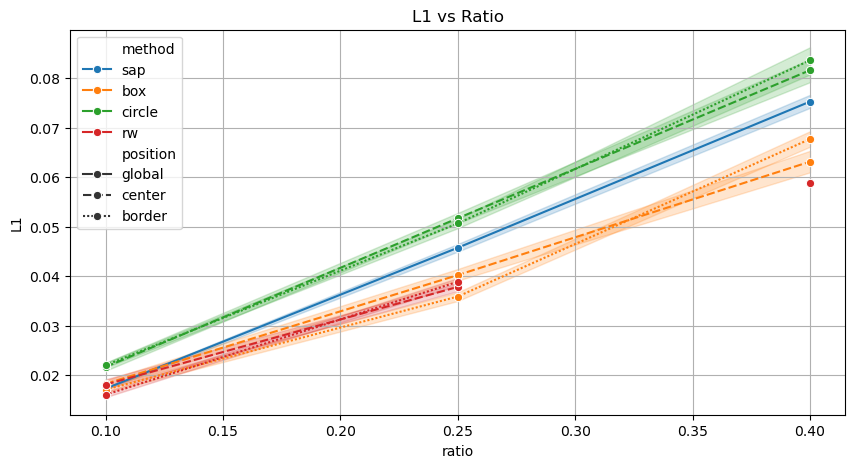

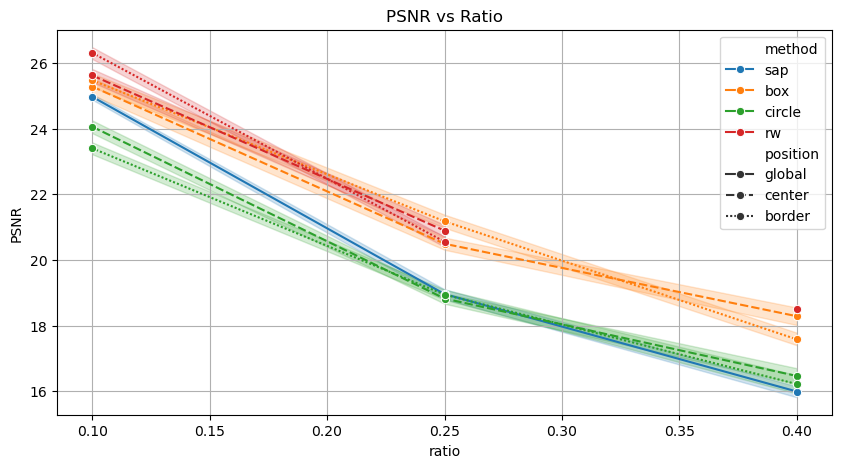

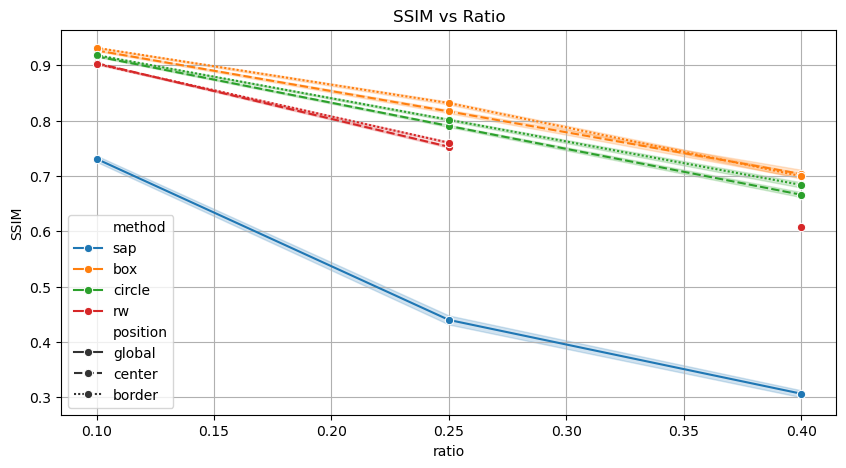

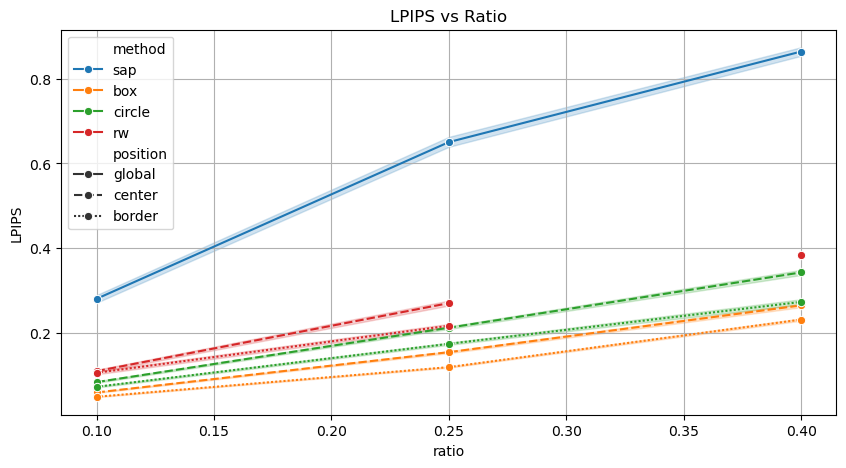

In [86]:
plot_metric_vs_ratio(df, metric_names)

In [92]:
def plot_method_comparison(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """
    Compares methods globally (averaged over ratio + position) arranged in 2 columns.
    """
    num_metrics = len(metrics)
    cols = 2
    rows = math.ceil(num_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    
    # Ensure axes is a 1D or 2D array even if single row/col
    axes = axes.flatten() if num_metrics > 1 else [axes]

    for i, metric in enumerate(metrics):
        sns.barplot(
            data=df,
            x="method",
            y=metric,
            errorbar="sd",
            ax=axes[i]
        )
        axes[i].set_title(f"{metric} by Method")
        axes[i].grid(alpha=0.3)

    # Hide any unused subplots if the number of metrics is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

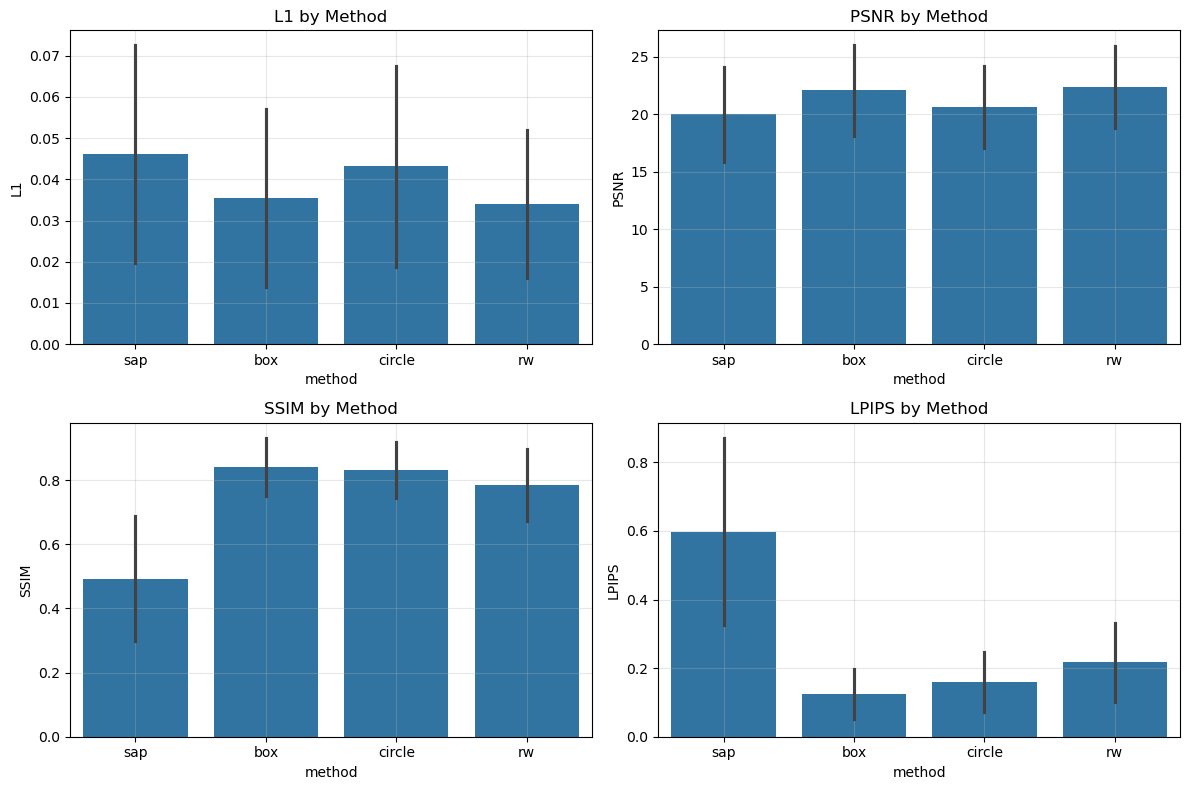

In [93]:
plot_method_comparison(df, metric_names)

In [96]:
def plot_position_effect(df, metrics=("L1", "PSNR", "SSIM", "LPIPS")):
    """Compares centered vs border masks in a 2-column grid layout."""
    n_metrics = len(metrics)
    cols = 2
    rows = int(np.ceil(n_metrics / cols))

    fig, axes = plt.subplots(
        rows, cols, figsize=(12, 4 * rows), squeeze=False
    )

    filtered_df = df[df["position"] != "global"]

    for idx, metric in enumerate(metrics):
        r, c = divmod(idx, cols)
        ax = axes[r, c]

        sns.barplot(
            data=filtered_df,
            x="position",
            y=metric,
            hue="method",
            errorbar="sd",
            ax=ax,
        )

        ax.set_title(f"{metric}: Center vs Border")
        ax.grid(True)

    # Hide any unused subplots (if an odd number of metrics is provided)
    for idx in range(n_metrics, rows * cols):
        r, c = divmod(idx, cols)
        fig.delaxes(axes[r, c])

    plt.tight_layout()
    plt.show()

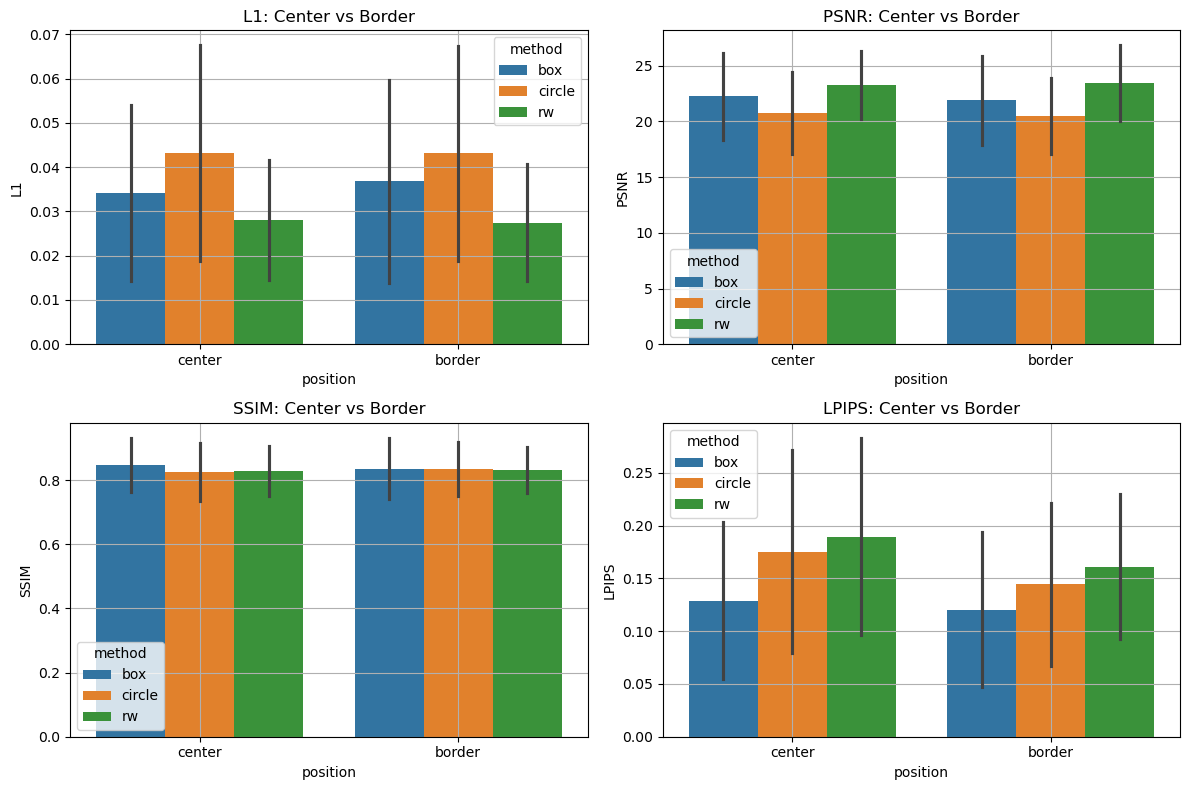

In [97]:
plot_position_effect(df, metric_names)

In [101]:
def plot_method_ratio_heatmap(df, metrics=["L1"]):
    """
    Heatmaps: method vs ratio averaged over images for a list of metrics in 2 columns.
    """
    n_metrics = len(metrics)
    cols = 2
    rows = math.ceil(n_metrics / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        pivot = df.pivot_table(
            values=metric,
            index="method",
            columns="ratio",
            aggfunc="mean"
        )
        sns.heatmap(pivot, annot=True, cmap="viridis", ax=axes[i])
        axes[i].set_title(f"{metric}: Method vs Ratio")

    # Hide any unused subplots (if n_metrics is odd)
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

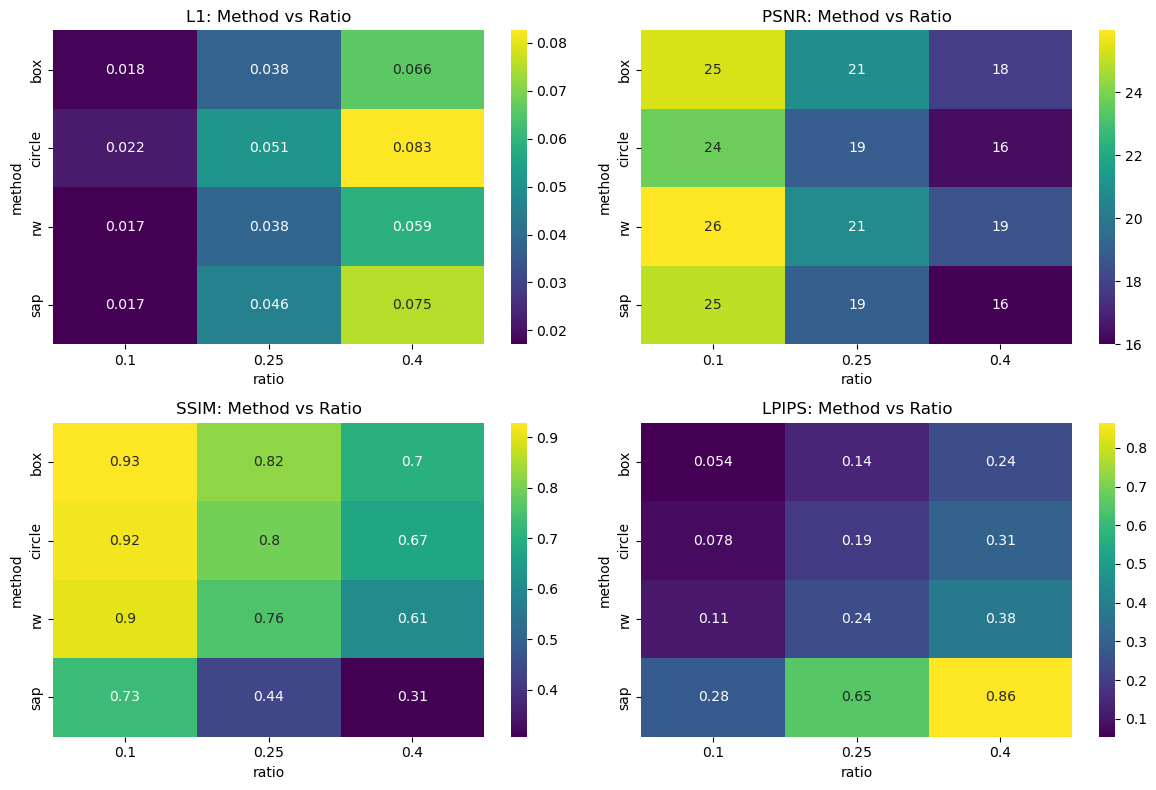

In [102]:
plot_method_ratio_heatmap(df, metric_names)

# + IDEA: CORRELATIONS BETWEEN METRICS?